In [1]:
# Import your existing types and functions
from typing import Optional, Union, Any
from dataclasses import dataclass
import random
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch

import pandas as pd
import torch
from torch import Tensor, einsum
from jaxtyping import Float, Int, Bool

from js_embedding_vis import write_inlined_config

from muutils.collect_warnings import CollateWarnings
from muutils.dbg import dbg, dbg_auto, dbg_tensor
import matplotlib.pyplot as plt


from spd.analysis.embed_vis import AnalysisConfig, coactivation_analysis, plot_embedding_label_grid
from spd.analysis.grouping import (
    CoactivationResults,
    CoactivationResultsGroup,
    get_coactivations,
)
from spd.data_utils import SparseFeatureDataset
from spd.experiments.resid_mlp.resid_mlp_dataset import ResidualMLPDataset
from spd.utils import get_device_torch
from spd.analysis.merge_matrix import GroupMerge, BatchedGroupMerge

/home/miv/projects/MATS/apd/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# magic autoreload
%load_ext autoreload
%autoreload 2

In [3]:
DEVICE = get_device_torch()
torch.set_grad_enabled(False)
print(f"Using device: {DEVICE = }")

Using device: DEVICE = device(type='cuda')


In [4]:
COACTIVATIONS = get_coactivations(
    model_path=Path("../data/mlp-decomp/model_30000.pth"),
    dataset_cls=ResidualMLPDataset,
    dataset_kwargs=dict(
        calc_labels=False,  # Our labels will be the output of the target model
        label_type=None,
        act_fn_name=None,
        label_fn_seed=None,
        label_coeffs=None,
        synced_inputs=None,
    ),
	dataloader_kwargs=dict(
		batch_size=999,
    ),
    coactivations_kwargs=dict(
        module_groups=[["layers.0.mlp_in", "layers.0.mlp_out"]],
		n_samples=999,
    ),
    device=DEVICE,
)["group_0"]



dbg_auto(COACTIVATIONS);

  warnings.warn(
/home/miv/projects/MATS/apd/.venv/lib/python3.11/site-packages/muutils/tensor_info.py:260: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  hist, bins = np.histogram(A_hist, bins=hist_bins)
[ <ipykernel>:24 ] COACTIVATIONS: <dict of len()=12, key_types={str}, val_types={Tensor, dict, float, int, list, ndarray}>
  co_occurrence_matrix: μ=4.71 σ=15.81 x̃=0.00 R=[0.00,219.00] ℙ˪=|█▆▅▁▂▃▁| shape=(200,200) dtype=torch.float32 device=cuda:0 ∇✗
  marginal_counts: μ=47.58 σ=72.45 x̃=9.00 R=[0.00,219.00] ℙ=|█    ▂ | shape=200 dtype=torch.float32 device=cuda:0 ∇✗
  module_slices:   <dict of len()=2, key_types={str}, val_types={slice}>
    layers.0.mlp_in: slice(0, 100, None)
    layers.0.mlp_out: slice(100, 200, None)
  modules: ['layers.0.mlp_in', 'layers.0.mlp_out']
  labels: shape=200 dtype=<U16
  component_masks: μ=0.02 σ=0.13 x̃=-0.00 R=[-0.05,1.00] ℙ˪=|█▅▅▅▄▅▅| shape=(999,200) dtype=torch.float32 device=cuda:0 ∇✗
  active_mask: μ=0.0

the above actually makes sense. the last 100 are the superimposed components which we expect to merge into one super-component.	

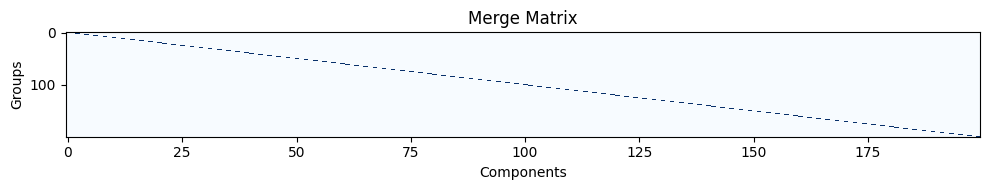

[ <ipykernel>:10 ] gm_downstream.group_idxs: μ=98.83 σ=57.45 x̃=99.00 R=[0,198] ℙ=|███████| shape=(19900,200) dtype=torch.int64 device=cpu ∇✗
[ <ipykernel>:11 ] "d" = 'd'
[ <ipykernel>:13 ] "e" = 'e'
[ <ipykernel>:14 ] gmd_m: μ=98.83 σ=57.45 x̃=99.00 R=[0,198] ℙ=|███████| shape=(19900,200) dtype=torch.int64 device=cpu ∇✗


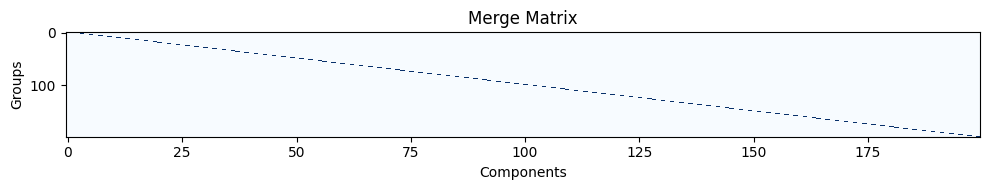

In [5]:
# gm = GroupMerge.random(
#     n_components=200,
#     k_groups=50,
#     ensure_groups_nonempty=True,
# )
gm_ident = GroupMerge.identity(n_components=200)

gm_ident.plot(figsize=(10, 2))
gm_downstream: BatchedGroupMerge = gm_ident.all_downstream_merged()
dbg_tensor(gm_downstream.group_idxs);
dbg("d")
gmd_m = gm_downstream.group_idxs
dbg("e")
dbg_tensor(gmd_m);
gm_downstream[0].plot(figsize=(10, 2))


$$
	F_g := \frac{\alpha}{n}
	\Bigg[
		d(A(g)) \cdot Q^T 
		+ Q \cdot d(A(g))^T
		- \Big(
			R \mathbf{1}^T
			+ \mathbf{1} R^T + \alpha^{-1}
		\Big) 
		\odot A(g)
	\Bigg]
$$

In [29]:
def compute_merge_costs(
    coact: Bool[Tensor, "k_groups k_groups"],
    merges: GroupMerge,
    alpha: float = 1.0,
) -> Float[Tensor, "k_groups k_groups"]:
    """Compute MDL costs for merge matrices"""
    device: torch.device = coact.device
    ranks: Float[Tensor, " k_groups"] = merges.components_per_group.to(device=device).float()
    diag: Float[Tensor, "k_groups"] = torch.diag(coact).to(device=device)

    # dbg_tensor(coact)
    # dbg_tensor(ranks)
    # dbg_tensor(diag)

    return alpha * (
        diag @ ranks.T
        + ranks @ diag.T
        - (
            ranks.unsqueeze(0) 
            + ranks.unsqueeze(1)
            + (1/alpha)
        ) * coact
    )

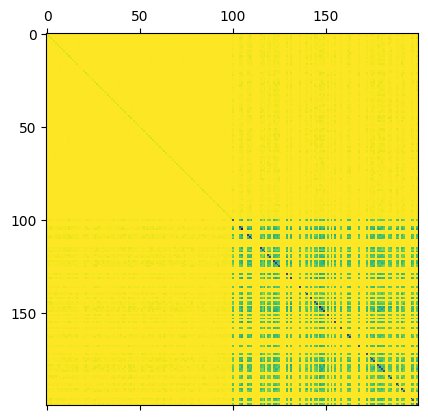

In [30]:
costs = compute_merge_costs(
	coact=COACTIVATIONS['co_occurrence_matrix'],
	merges=gm_ident,
)
plt.matshow(costs.cpu(), cmap='viridis')

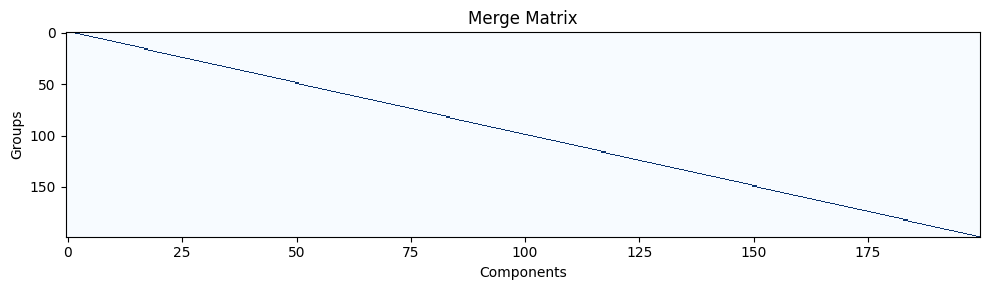

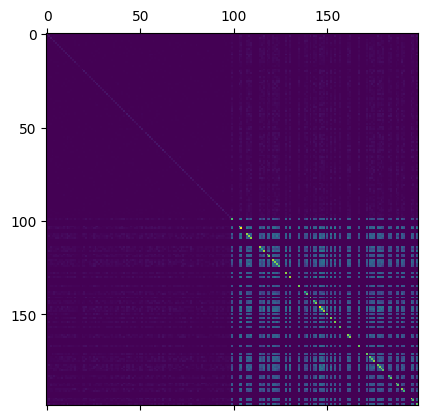

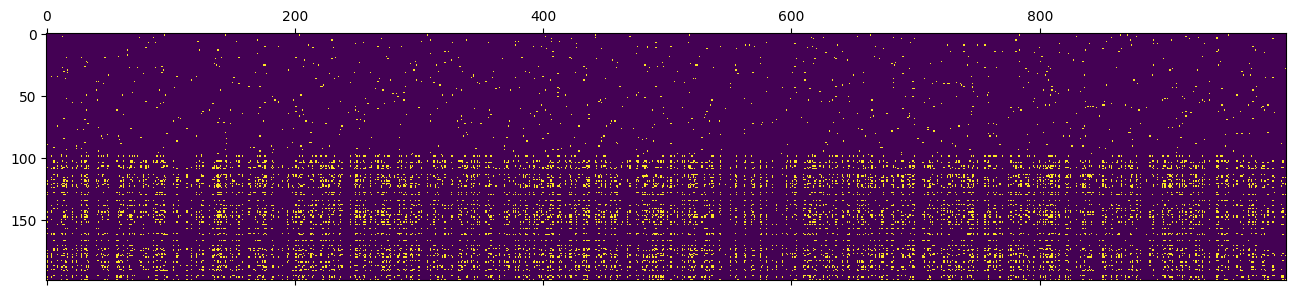

In [31]:
def recompute_coacts(
	coact: Float[Tensor, "k_groups k_groups"],
	merges: GroupMerge,
	merge_pair: tuple[int, int],
	activation_mask: Bool[Tensor, "samples k_groups"],
) -> tuple[
		GroupMerge,
		Float[Tensor, "k_groups-1 k_groups-1"],
		Bool[Tensor, "samples k_groups"],
	]:
	# check shape
	k_groups: int = coact.shape[0]
	assert coact.shape[1] == k_groups, "Coactivation matrix must be square"

	# activations of the new merged group
	activation_mask_grp: Bool[Tensor, " samples"] = activation_mask[:, merge_pair[0]] + activation_mask[:, merge_pair[1]]

	# coactivations with the new merged group
	# dbg_tensor(activation_mask_grp)
	# dbg_tensor(activation_mask)
	coact_with_merge: Bool[Tensor, " k_groups"] = (activation_mask_grp.float() @ activation_mask.float()).bool()
	new_group_idx: int = min(merge_pair)
	remove_idx: int = max(merge_pair)
	new_group_self_coact: float = activation_mask_grp.float().sum().item()
	# dbg_tensor(coact_with_merge)

	# assemble the merge pair
	merge_new: GroupMerge = merges.merge_groups(
		merge_pair[0],
		merge_pair[1],
	)
	old_to_new_idx: dict[int|None, int| None] = merge_new.old_to_new_idx # type: ignore
	assert old_to_new_idx[None] == new_group_idx, "New group index should be the minimum of the merge pair"
	assert old_to_new_idx[new_group_idx] is None
	assert old_to_new_idx[remove_idx] is None
	# TODO: check that the rest are in order? probably not necessary

	# reindex coactivations
	coact_temp: Float[Tensor, "k_groups k_groups"] = coact.clone()
	# add in the similarities with the new group
	coact_temp[new_group_idx, :] = coact_with_merge
	coact_temp[:, new_group_idx] = coact_with_merge
	# delete the old group
	mask: Bool[Tensor, " k_groups"] = torch.ones(coact_temp.shape[0], dtype=torch.bool, device=coact_temp.device)
	mask[remove_idx] = False
	coact_new: Float[Tensor, "k_groups-1 k_groups-1"] = coact_temp[mask, :][:, mask]
	# add in the self-coactivation of the new group
	coact_new[new_group_idx, new_group_idx] = new_group_self_coact
	# dbg_tensor(coact_new)

	# reindex mask
	activation_mask_new: Float[Tensor, "samples ..."] = activation_mask.clone()
	# add in the new group
	activation_mask_new[:, new_group_idx] = activation_mask_grp
	# remove the old group
	activation_mask_new = activation_mask_new[:, mask]
	
	# dbg_tensor(activation_mask_new)

	return (
		merge_new,
		coact_new,
		activation_mask_new,
	)


rc_test = recompute_coacts(
	coact=COACTIVATIONS['co_occurrence_matrix'],
	merges=gm_ident,
	merge_pair=(0, 1),
	activation_mask=COACTIVATIONS['active_mask'],
)
rc_test[0].plot()
plt.show()
plt.matshow(rc_test[1].cpu(), cmap='viridis')
plt.show()
plt.matshow(rc_test[2].T.cpu(), cmap='viridis')
plt.show()


[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 0: merging pair min_pair=(105, 108) pair_cost=18750.0 non_diag_costs_range[0]=18750.0 max_considered_cost=18764.1'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 1: merging pair min_pair=(109, 146) pair_cost=19191.0 non_diag_costs_range[0]=19185.0 max_considered_cost=19198.65'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 2: merging pair min_pair=(146, 178) pair_cost=19617.0 non_diag_costs_range[0]=19611.0 max_considered_cost=19624.65'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 3: merging pair min_pair=

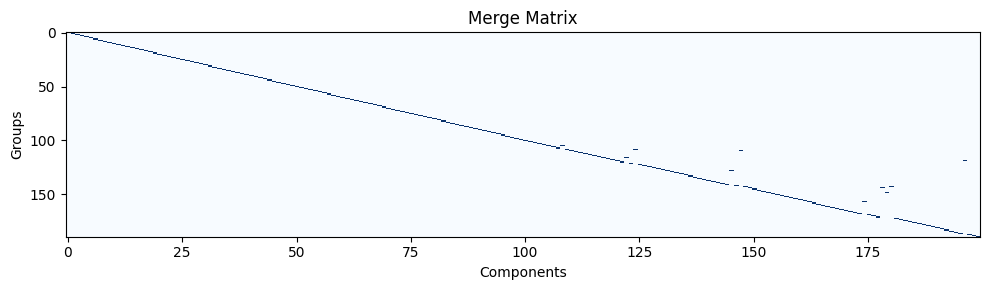

[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 10: merging pair min_pair=(182, 137) pair_cost=22705.0 non_diag_costs_range[0]=22699.0 max_considered_cost=22710.55'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 11: merging pair min_pair=(169, 121) pair_cost=23106.0 non_diag_costs_range[0]=23097.0 max_considered_cost=23108.25'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 12: merging pair min_pair=(158, 104) pair_cost=23506.0 non_diag_costs_range[0]=23497.0 max_considered_cost=23508.25'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 13: merging pair min_

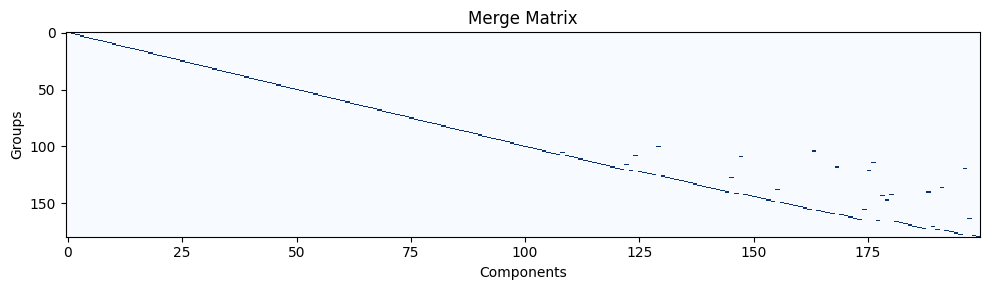

[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 20: merging pair min_pair=(132, 166) pair_cost=26752.0 non_diag_costs_range[0]=26752.0 max_considered_cost=26761.3'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 21: merging pair min_pair=(145, 173) pair_cost=27173.0 non_diag_costs_range[0]=27173.0 max_considered_cost=27182.15'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 22: merging pair min_pair=(151, 177) pair_cost=27557.0 non_diag_costs_range[0]=27551.0 max_considered_cost=27559.55'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 23: merging pair min_p

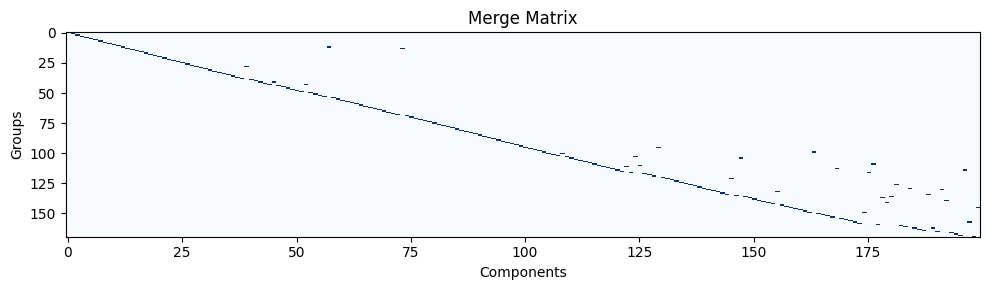

[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 30: merging pair min_pair=(57, 79) pair_cost=29070.0 non_diag_costs_range[0]=29070.0 max_considered_cost=29070.3'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 31: merging pair min_pair=(10, 81) pair_cost=29118.0 non_diag_costs_range[0]=29118.0 max_considered_cost=29118.3'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 32: merging pair min_pair=(5, 2) pair_cost=29136.0 non_diag_costs_range[0]=29136.0 max_considered_cost=29136.3'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 33: merging pair min_pair=(6, 17

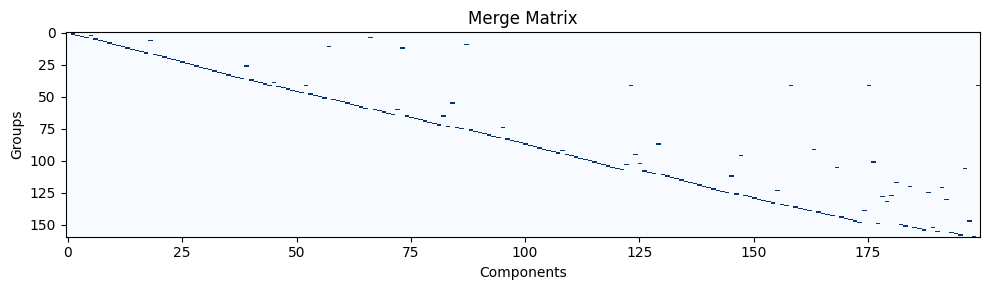

[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 40: merging pair min_pair=(130, 41) pair_cost=31873.0 non_diag_costs_range[0]=31873.0 max_considered_cost=31873.45'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 41: merging pair min_pair=(41, 127) pair_cost=33251.0 non_diag_costs_range[0]=33251.0 max_considered_cost=33251.55'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 42: merging pair min_pair=(41, 92) pair_cost=34593.0 non_diag_costs_range[0]=34593.0 max_considered_cost=34593.65'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 43: merging pair min_pair

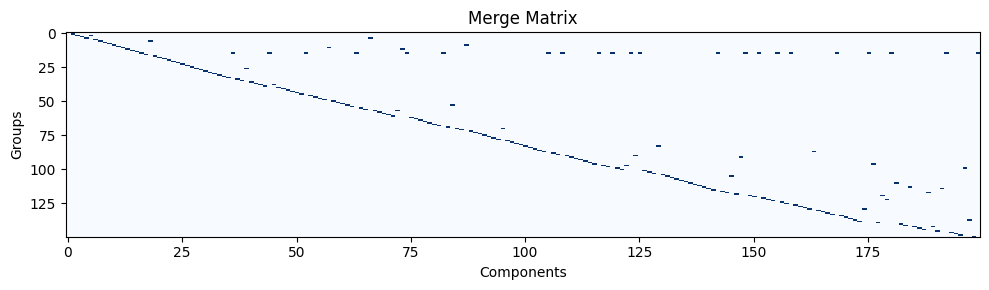

[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 50: merging pair min_pair=(50, 15) pair_cost=45165.0 non_diag_costs_range[0]=45164.0 max_considered_cost=45165.3'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 51: merging pair min_pair=(15, 118) pair_cost=46267.0 non_diag_costs_range[0]=46267.0 max_considered_cost=46268.35'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 52: merging pair min_pair=(80, 15) pair_cost=47450.0 non_diag_costs_range[0]=47449.0 max_considered_cost=47450.45'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 53: merging pair min_pair=(

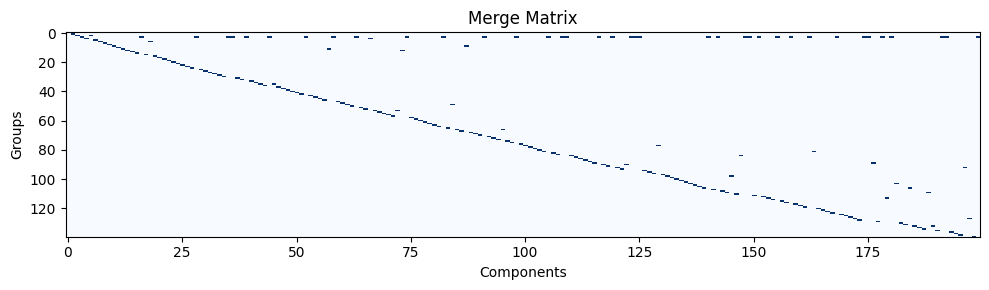

[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 60: merging pair min_pair=(74, 3) pair_cost=57812.0 non_diag_costs_range[0]=57811.0 max_considered_cost=57813.05'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 61: merging pair min_pair=(3, 22) pair_cost=58891.0 non_diag_costs_range[0]=58890.0 max_considered_cost=58892.1'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 62: merging pair min_pair=(71, 3) pair_cost=59974.0 non_diag_costs_range[0]=59973.0 max_considered_cost=59975.15'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 63: merging pair min_pair=(3, 2

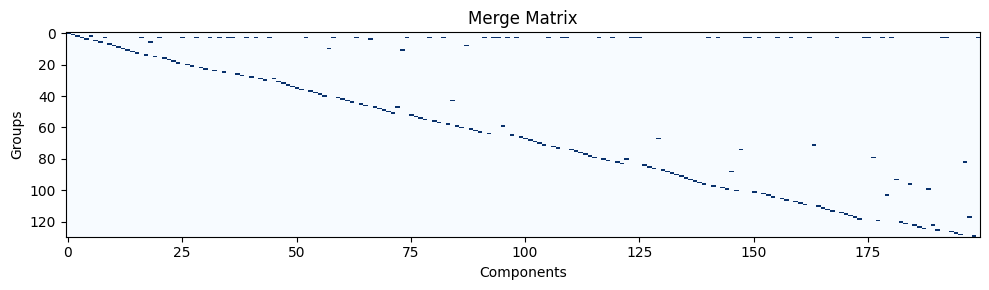

[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 70: merging pair min_pair=(3, 22) pair_cost=68988.0 non_diag_costs_range[0]=68987.0 max_considered_cost=68989.55'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 71: merging pair min_pair=(61, 3) pair_cost=70073.0 non_diag_costs_range[0]=70072.0 max_considered_cost=70074.6'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 72: merging pair min_pair=(45, 3) pair_cost=71160.0 non_diag_costs_range[0]=71159.0 max_considered_cost=71161.65'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 73: merging pair min_pair=(64, 

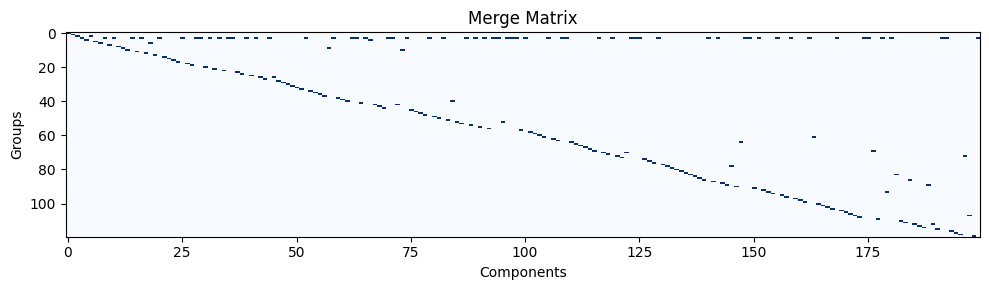

[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 80: merging pair min_pair=(86, 3) pair_cost=81245.0 non_diag_costs_range[0]=81245.0 max_considered_cost=81248.15'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 81: merging pair min_pair=(36, 3) pair_cost=82660.0 non_diag_costs_range[0]=82659.0 max_considered_cost=82662.25'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 82: merging pair min_pair=(20, 3) pair_cost=83873.0 non_diag_costs_range[0]=83872.0 max_considered_cost=83875.3'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 83: merging pair min_pair=(3, 2

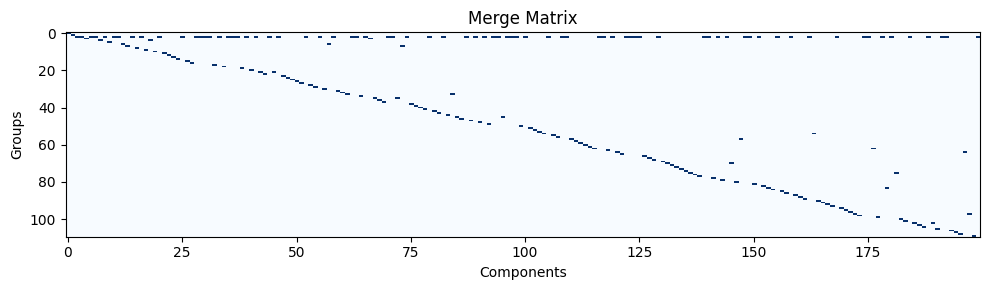

[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 90: merging pair min_pair=(2, 9) pair_cost=94896.0 non_diag_costs_range[0]=94895.0 max_considered_cost=94898.85'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 91: merging pair min_pair=(53, 2) pair_cost=96016.0 non_diag_costs_range[0]=96016.0 max_considered_cost=96019.9'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 92: merging pair min_pair=(2, 21) pair_cost=97171.0 non_diag_costs_range[0]=97170.0 max_considered_cost=97174.0'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 93: merging pair min_pair=(2, 8) 

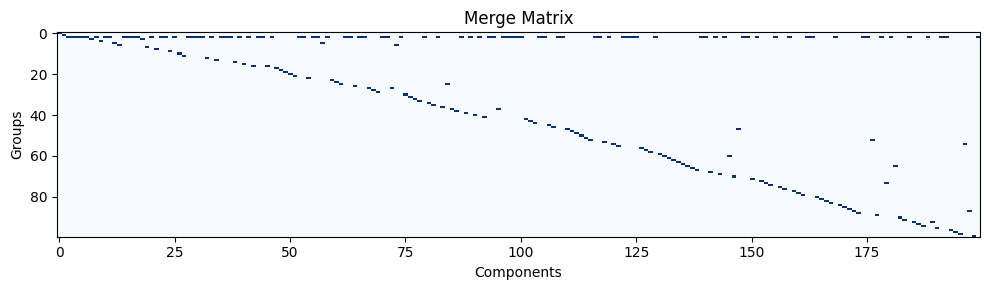

[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 100: merging pair min_pair=(28, 2) pair_cost=107854.0 non_diag_costs_range[0]=107853.0 max_considered_cost=107857.45'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 101: merging pair min_pair=(19, 2) pair_cost=109151.0 non_diag_costs_range[0]=109150.0 max_considered_cost=109154.5'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 102: merging pair min_pair=(21, 2) pair_cost=110276.0 non_diag_costs_range[0]=110275.0 max_considered_cost=110279.55'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 103: merging pair m

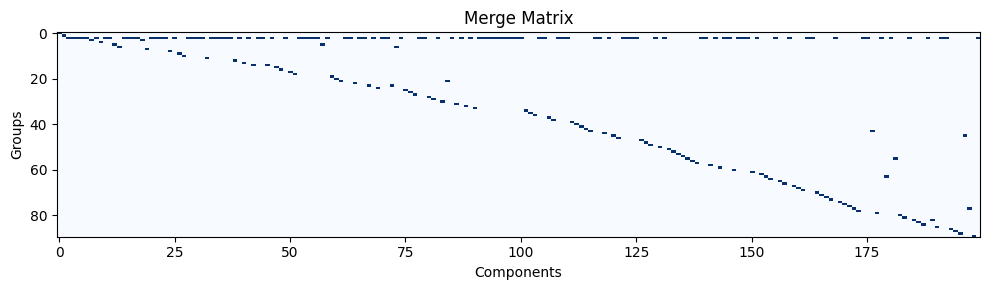

[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 110: merging pair min_pair=(2, 1) pair_cost=121485.0 non_diag_costs_range[0]=121484.0 max_considered_cost=121489.1'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 111: merging pair min_pair=(1, 76) pair_cost=123011.0 non_diag_costs_range[0]=123011.0 max_considered_cost=123016.15'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 112: merging pair min_pair=(24, 1) pair_cost=124298.0 non_diag_costs_range[0]=124297.0 max_considered_cost=124302.25'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 113: merging pair mi

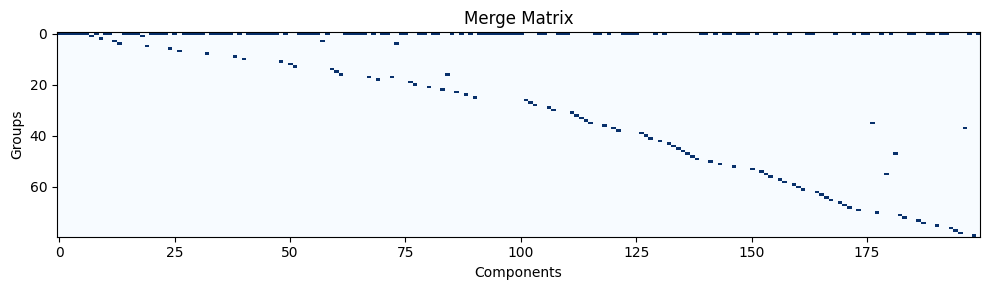

[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 120: merging pair min_pair=(37, 0) pair_cost=135693.0 non_diag_costs_range[0]=135693.0 max_considered_cost=135698.75'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 121: merging pair min_pair=(0, 24) pair_cost=136864.0 non_diag_costs_range[0]=136863.0 max_considered_cost=136868.85'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 122: merging pair min_pair=(0, 6) pair_cost=138015.0 non_diag_costs_range[0]=138014.0 max_considered_cost=138019.9'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 123: merging pair mi

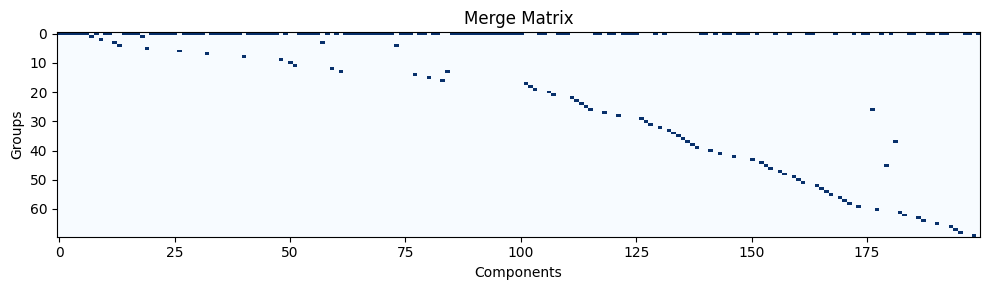

[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 130: merging pair min_pair=(0, 13) pair_cost=148795.0 non_diag_costs_range[0]=148795.0 max_considered_cost=148801.35'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 131: merging pair min_pair=(7, 0) pair_cost=151786.0 non_diag_costs_range[0]=151785.0 max_considered_cost=151791.45'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 132: merging pair min_pair=(1, 0) pair_cost=152940.0 non_diag_costs_range[0]=152940.0 max_considered_cost=152946.5'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 133: merging pair min

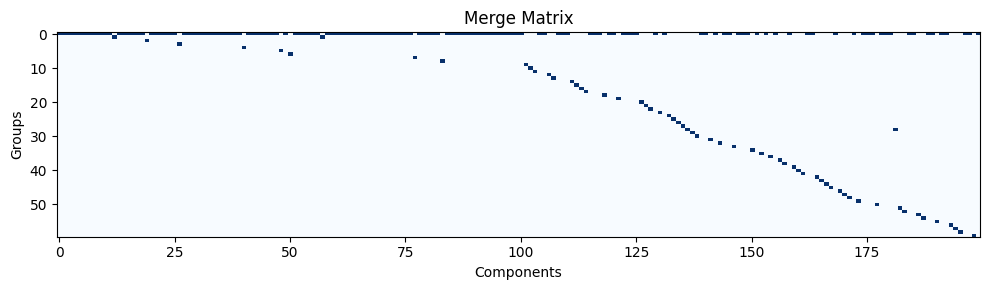

[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 140: merging pair min_pair=(0, 8) pair_cost=164585.0 non_diag_costs_range[0]=164584.0 max_considered_cost=164591.1'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 141: merging pair min_pair=(0, 4) pair_cost=165748.0 non_diag_costs_range[0]=165747.0 max_considered_cost=165754.15'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 142: merging pair min_pair=(2, 0) pair_cost=167185.0 non_diag_costs_range[0]=167184.0 max_considered_cost=167191.2'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 143: merging pair min_p

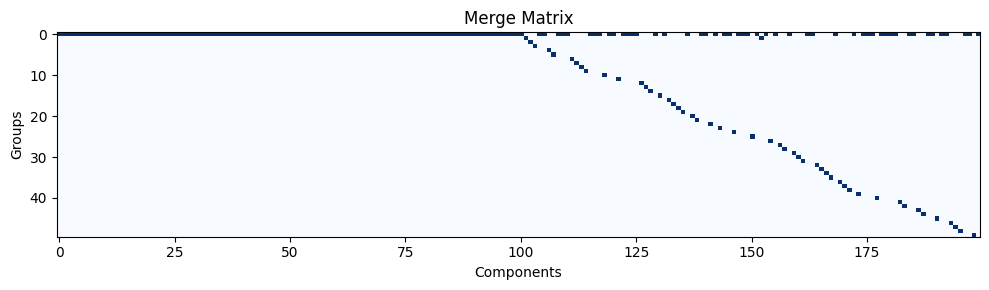

[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 150: merging pair min_pair=(5, 9) pair_cost=177600.0 non_diag_costs_range[0]=177600.0 max_considered_cost=177600.0'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 151: merging pair min_pair=(10, 39) pair_cost=177600.0 non_diag_costs_range[0]=177600.0 max_considered_cost=177600.0'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 152: merging pair min_pair=(43, 46) pair_cost=177600.0 non_diag_costs_range[0]=177600.0 max_considered_cost=177600.0'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 153: merging pair mi

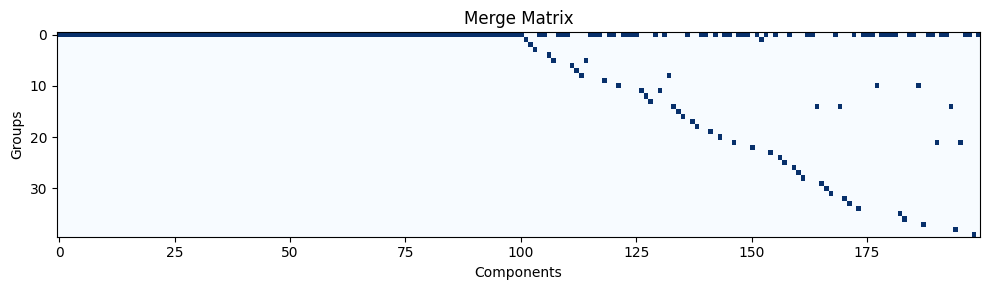

[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 160: merging pair min_pair=(9, 10) pair_cost=177600.0 non_diag_costs_range[0]=177600.0 max_considered_cost=177600.0'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 161: merging pair min_pair=(38, 4) pair_cost=177600.0 non_diag_costs_range[0]=177600.0 max_considered_cost=177600.0'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 162: merging pair min_pair=(30, 28) pair_cost=177600.0 non_diag_costs_range[0]=177600.0 max_considered_cost=177600.0'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 163: merging pair mi

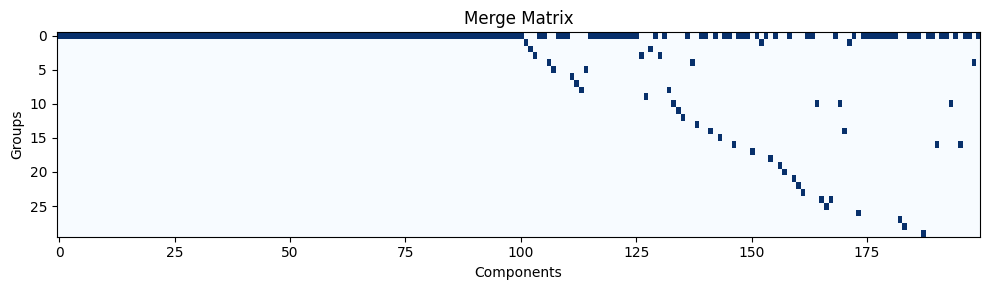

[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 170: merging pair min_pair=(16, 25) pair_cost=183520.0 non_diag_costs_range[0]=183520.0 max_considered_cost=183520.0'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 171: merging pair min_pair=(23, 9) pair_cost=183520.0 non_diag_costs_range[0]=183520.0 max_considered_cost=183520.0'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 172: merging pair min_pair=(16, 1) pair_cost=183520.0 non_diag_costs_range[0]=183520.0 max_considered_cost=183520.0'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 173: merging pair mi

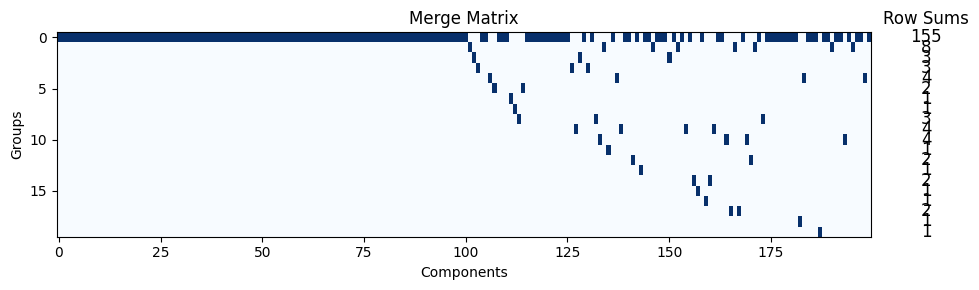

[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 180: merging pair min_pair=(12, 1) pair_cost=183520.0 non_diag_costs_range[0]=183520.0 max_considered_cost=183520.0'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 181: merging pair min_pair=(10, 2) pair_cost=183520.0 non_diag_costs_range[0]=183520.0 max_considered_cost=183520.0'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 182: merging pair min_pair=(7, 16) pair_cost=183520.0 non_diag_costs_range[0]=183520.0 max_considered_cost=183520.0'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 183: merging pair min

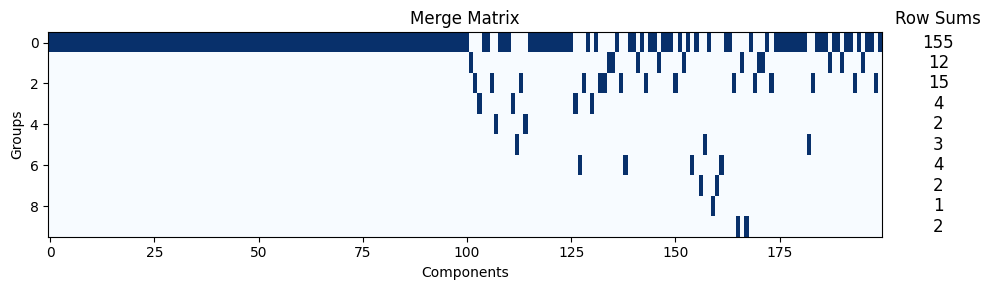

[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 190: merging pair min_pair=(9, 5) pair_cost=183520.0 non_diag_costs_range[0]=183520.0 max_considered_cost=183520.0'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 191: merging pair min_pair=(3, 5) pair_cost=183520.0 non_diag_costs_range[0]=183520.0 max_considered_cost=183520.0'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 192: merging pair min_pair=(6, 3) pair_cost=183520.0 non_diag_costs_range[0]=183520.0 max_considered_cost=183520.0'
[ <ipykernel>:50 -> merge_iteration ] f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}" = 'Iteration 193: merging pair min_pa

RuntimeError: min(): Expected reduction dim to be specified for input.numel() == 0. Specify the reduction dim with the 'dim' argument.

In [55]:
def merge_iteration(
	coact: Bool[Tensor, "c_components c_components"],
	activation_mask: Bool[Tensor, "samples c_components"],
    alpha: float = 1.0,
	iters: int = 100,
	check_threshold: float = 0.05,
):
	# check shapes
	c_components: int = coact.shape[0]
	assert coact.shape[1] == c_components, "Coactivation matrix must be square"
	assert activation_mask.shape[1] == c_components, "Activation mask must match coactivation matrix shape"

	# start with an identity merge
	current_merge: GroupMerge = GroupMerge.identity(n_components=c_components)
	k_groups: int = c_components
	current_coact: Float[Tensor, "k_groups k_groups"] = coact.clone()
	current_act_mask: Bool[Tensor, "samples k_groups"] = activation_mask.clone()

	# iteration counter
	i: int = 0
	while i < iters:
		# compute costs
		costs: Float[Tensor, "c_components c_components"] = compute_merge_costs(
			coact=current_coact,
			merges=current_merge,
			alpha=alpha,
		)
		# dbg_tensor(costs)

		# find the minimum cost pair
		non_diag_costs: Float[Tensor, ""] = costs[~torch.eye(k_groups, dtype=torch.bool)]
		# dbg_tensor(non_diag_costs)
		non_diag_costs_range: tuple[float, float] = (non_diag_costs.min().item(), non_diag_costs.max().item())
		# dbg(non_diag_costs_range)
		max_considered_cost: float = (non_diag_costs_range[1] - non_diag_costs_range[0]) * check_threshold + non_diag_costs_range[0]
		# dbg(max_considered_cost)

		considered_idxs = torch.where(costs <= max_considered_cost)
		considered_idxs = torch.stack(considered_idxs, dim=1)
		# remove from considered_idxs where i == j
		considered_idxs = considered_idxs[considered_idxs[:, 0] != considered_idxs[:, 1]]
		
		# dbg_tensor(considered_idxs)

		# randomly select one of the considered pairs
		min_pair: tuple[int, int] = tuple(considered_idxs[random.randint(0, considered_idxs.shape[0] - 1)].tolist())
		pair_cost: float = costs[min_pair[0], min_pair[1]].item()

		# merge the pair
		dbg(f"Iteration {i}: merging pair {min_pair=} {pair_cost=} {non_diag_costs_range[0]=} {max_considered_cost=}")
		current_merge, current_coact, current_act_mask = recompute_coacts(
			coact=current_coact,
			merges=current_merge,
			merge_pair=min_pair,
			activation_mask=current_act_mask,
		)

		k_groups -= 1
		assert current_coact.shape[0] == k_groups, "Coactivation matrix shape should match number of groups"
		assert current_coact.shape[1] == k_groups, "Coactivation matrix shape should match number of groups"
		assert current_act_mask.shape[1] == k_groups, "Activation mask shape should match number of groups"

		i += 1

		if i % 10 == 0:
			current_merge.plot()
			plt.show()

merge_iteration(
	coact=COACTIVATIONS['co_occurrence_matrix'],
	activation_mask=COACTIVATIONS['active_mask'],
	alpha=1.0,
	iters=200,
)

In [ ]:


def merge_iteration(
    coact: Float[Tensor, "k_groups k_groups"],
    active_mask: Bool[Tensor, "samples n_components"],
    merge: GroupMerge,
    alpha: float = 1.0,
) -> dict[str, Any]:
    n_samples: int = active_mask.shape[0]
    n_components: int = active_mask.shape[1]
    assert n_components == coact.shape[0] == coact.shape[1]




    return {}

    


In [ ]:
dbg_tensor(COACTIVATIONS['active_mask'])
merge_costs = compute_merge_costs(
    coact=COACTIVATIONS['active_mask'],
    bgm=gm_downstream,
    alpha=1.0,
)
dbg_tensor(merge_costs);

In [ ]:
n_downstream: int = gm_ident.k_groups
merge_costs_grid = torch.full((n_downstream, n_downstream), torch.nan)
for g in range(gm_downstream.batch_size):
    mp = gm_downstream.meta[g]['merge_pair']
    merge_costs_grid[mp] = merge_costs[g].cpu()
    merge_costs_grid[mp[1], mp[0]] = merge_costs[g].cpu()

plt.matshow(merge_costs_grid)
plt.colorbar(label='Merge Cost')

In [ ]:
def greedy_merge(
	activation_mask: Bool[Tensor, "n_samples n_components"],
	target_k_groups: int,
    alpha: float = 1.0,
	initial_guess: GroupMerge|None = None,
):
	n_samples: int; n_components: int
	n_samples, n_components = activation_mask.shape

	current_merge: GroupMerge
	if initial_guess is None:
		current_merge = GroupMerge.identity(n_components)
	else:
		current_merge = initial_guess


	dbg_tensor(current_merge.to_matrix())

	while current_merge.k_groups > target_k_groups:
		# Compute merge costs for all pairs of groups
		adm: BatchedGroupMerge = current_merge.all_downstream_merged()
		dbg_tensor(adm.to_matrix())
		merge_costs: Tensor = compute_merge_costs(
			coact=activation_mask,
			bgm=adm,
			alpha=alpha,
		)

		# Find the pair with the lowest merge cost
		min_cost, min_pair = torch.min(merge_costs, dim=0)
		dbg(min_cost)
		dbg(min_pair)

		# Merge the pair with the lowest cost
		current_merge = current_merge.merge_groups(min_pair)
		dbg(f"Merging {min_pair} with cost {min_cost.item()}")
		dbg_tensor(current_merge.to_matrix())



greedy_merge(COACTIVATIONS['active_mask'], 10)

In [ ]:


def generate_all_merge_matrices(n_components: int, k: int, device=None) -> Bool[Tensor, "n_matrices k n_components"]:
    """Generate all possible merge matrices as single tensor"""
    if device is None:
        device = torch.device('cpu')
    
    # Total possibilities: k^n_components
    n_total = k ** n_components
    
    # Generate all base-k assignments
    assignments = torch.zeros(n_total, n_components, dtype=torch.long, device=device)
    
    for i in range(n_total):
        temp = i
        for j in range(n_components):
            assignments[i, j] = temp % k
            temp //= k
    
    # Convert to one-hot merge matrices
    merge_matrices = torch.zeros(n_total, k, n_components, dtype=torch.bool, device=device)
    batch_indices = torch.arange(n_total, device=device).unsqueeze(1)  # [n_total, 1]
    component_indices = torch.arange(n_components, device=device).unsqueeze(0)  # [1, n_components]
    
    merge_matrices[batch_indices, assignments, component_indices] = True
    
    # Filter out matrices with empty groups
    group_counts = merge_matrices.sum(dim=2)  # [n_total, k]
    valid_mask = (group_counts > 0).all(dim=1)  # [n_total]
    
    return merge_matrices[valid_mask]


def find_all_merge_costs(
    co_occurrence_matrix: Float[Tensor, "n_components n_components"],
    marginal_counts: Float[Tensor, "n_components"],
    k: int,
    alpha: float = 1.0,
) -> Float[Tensor, "n_matrices"]:
    """Return costs for all possible merge matrices"""
    all_matrices = generate_all_merge_matrices(marginal_counts.shape[0], k, marginal_counts.device)
    return compute_merge_costs(co_occurrence_matrix, marginal_counts, all_matrices, alpha)


def greedy_merge_search(
    co_occurrence_matrix: Float[Tensor, "n_components n_components"],
    marginal_counts: Float[Tensor, "n_components"],
    k: int,
    alpha: float = 1.0,
    temperature: float = 0.0,
    seed: Optional[int] = None,
) -> tuple[Bool[Tensor, "k n_components"], float]:
    """Greedy search with optional temperature sampling"""
    if seed is not None:
        torch.manual_seed(seed)
    
    n_components = marginal_counts.shape[0]
    device = marginal_counts.device
    
    # Start with identity
    merge_matrix = torch.eye(n_components, dtype=torch.bool, device=device)
    current_k = n_components
    
    while current_k > k:
        # Generate all possible merge candidates
        candidates = []
        
        for i in range(current_k):
            for j in range(i + 1, current_k):
                # Create candidate by merging groups i and j
                candidate = merge_matrix.clone()
                candidate[i] = candidate[i] | candidate[j]
                
                # Remove group j by shifting
                if j < current_k - 1:
                    candidate[j:current_k-1] = candidate[j+1:current_k]
                candidate = candidate[:current_k-1]
                
                candidates.append(candidate)
        
        # Compute costs for all candidates
        if len(candidates) > 0:
            candidate_stack = torch.stack(candidates)  # [n_candidates, current_k-1, n_components]
            
            # Compute current cost
            current_cost = compute_merge_costs(co_occurrence_matrix, marginal_counts, merge_matrix, alpha)
            
            # Compute candidate costs
            candidate_costs = compute_merge_costs(co_occurrence_matrix, marginal_counts, candidate_stack, alpha)
            cost_deltas = candidate_costs - current_cost
            
            # Select based on temperature
            if temperature == 0.0:
                best_idx = cost_deltas.argmin().item()
            else:
                probs = torch.softmax(-cost_deltas / temperature, dim=0)
                best_idx = torch.multinomial(probs, 1).item()
            
            merge_matrix = candidates[best_idx]
            current_k -= 1
        else:
            break
    
    final_cost = compute_merge_costs(co_occurrence_matrix, marginal_counts, merge_matrix, alpha)
    return merge_matrix, final_cost